<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# **Procesamiento de Lenguaje Natural**
## **Desafío 4 – Traductor**

### 1. Importamos las librerías necesarias

In [31]:
import time, pickle, os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import (Input, LSTM, Dense, Embedding,
                                      Dropout, AdditiveAttention, Concatenate,
                                      Dot, Activation, Lambda)
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K
import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


### 2. Descargamos el dataset

In [32]:
if not os.path.exists('spa-eng'):
    os.system("curl -L -o spa-eng.zip http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip")
    os.system("unzip -q spa-eng.zip")

with open("./spa-eng/spa.txt") as f:
    lines = f.read().split("\n")[:-1]

print(f"Líneas disponibles: {len(lines)}")

Líneas disponibles: 118964


### 3. Cargamos los datos (40.000 oraciones)

In [33]:
MAX_NUM_SENTENCES = 40000
np.random.seed(40)
np.random.shuffle(lines)

input_sentences, output_sentences, output_sentences_inputs = [], [], []

for i, line in enumerate(lines):
    if i >= MAX_NUM_SENTENCES:
        break
    if '\t' not in line:
        continue
    input_sentence, output = line.rstrip().split('\t')[:2]
    output_sentences.append(output + ' <eos>')
    output_sentences_inputs.append('<sos> ' + output)
    input_sentences.append(input_sentence)

print(f"Oraciones cargadas: {len(input_sentences)}")

Oraciones cargadas: 40000


### 4. Longitudes de secuencia corregidas

**Mejora 1**: usamos `max_input_len = 22` y `max_out_len = 26`, derivados del análisis estadístico real del dataset (p99 = 15/16 palabras). El modelo anterior que se probo usaba 30/35, generando ~15 tokens de padding innecesarios al inicio de cada secuencia.

In [34]:
MAX_VOCAB_SIZE = 15000

# ── MEJORA 1: longitudes corregidas según el análisis ──
max_input_len = 22   # antes: 30  | cubre p99=15 con margen
max_out_len   = 26   # antes: 35  | cubre p99=16 con margen

input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
word2idx_inputs = input_tokenizer.word_index

output_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n'
)
output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
word2idx_outputs = output_tokenizer.word_index

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)

print(f"Vocabulario EN: {len(word2idx_inputs)} | ES: {len(word2idx_outputs)}")
print(f"max_input_len={max_input_len}  max_out_len={max_out_len}")

Vocabulario EN: 9120 | ES: 16144
max_input_len=22  max_out_len=26


### 5. Padding de secuencias

In [35]:
encoder_input_sequences  = pad_sequences(input_integer_seq,        maxlen=max_input_len)
decoder_input_sequences  = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
decoder_output_sequences = pad_sequences(output_integer_seq,       maxlen=max_out_len, padding='post')

### 6. `tf.data.Dataset`

In [36]:
def make_dataset(enc_seqs, dec_in_seqs, dec_out_seqs, batch_size, num_classes):
    n = len(enc_seqs)

    def generator():
        for i in range(n):
            yield (enc_seqs[i].astype(np.int32),
                   dec_in_seqs[i].astype(np.int32),
                   dec_out_seqs[i].astype(np.int32))

    def encode_one_hot(enc, dec_in, dec_out):
        y = tf.one_hot(dec_out, depth=num_classes)
        return (enc, dec_in), y

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(max_input_len,), dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
        )
    )
    ds = ds.map(encode_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

BATCH_SIZE = 64
val_split  = 0.15
split_idx  = int(len(encoder_input_sequences) * (1 - val_split))

train_ds = make_dataset(encoder_input_sequences[:split_idx],
                        decoder_input_sequences[:split_idx],
                        decoder_output_sequences[:split_idx],
                        BATCH_SIZE, num_words_output)
val_ds   = make_dataset(encoder_input_sequences[split_idx:],
                        decoder_input_sequences[split_idx:],
                        decoder_output_sequences[split_idx:],
                        BATCH_SIZE, num_words_output)

print(f"Train: {split_idx} | Val: {len(encoder_input_sequences)-split_idx}")

Train: 34000 | Val: 6000


### 7. Embeddings GloVe de 50 dimensiones + proyección Dense a 128d

**Mejora 2**: en el modelo anterior se usaban embeddings GloVe de **50 dimensiones** con `trainable=False`. Ahora usamos **100 dimensiones** (mayor capacidad semántica) y activamos `trainable=True` para que los vectores se ajusten durante el entrenamiento, adaptándose al dominio de traducción español-inglés.

Ciertos patrones de este dataset (frases cortas, vocabulario cotidiano) difieren de ese dominio. Permitir que los embeddings se actualicen da al modelo la flexibilidad de refinar esas representaciones.

In [37]:
def _is_valid_pickle(path):
    try:
        with open(path, 'rb') as f:
            head = f.read(20)
        return b'<html' not in head.lower() and b'<!doctype' not in head.lower()
    except Exception:
        return False

_PKL_PATH = 'gloveembedding.pkl'
_FILE_ID  = '1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94'

if not os.path.exists(_PKL_PATH) or not _is_valid_pickle(_PKL_PATH):
    print("Descargando GloVe embeddings...")
    try:
        import gdown
        gdown.download(id=_FILE_ID, output=_PKL_PATH, quiet=False)
    except Exception:
        os.system(f"curl -L -o {_PKL_PATH} 'https://drive.google.com/u/0/uc?id={_FILE_ID}&export=download&confirm=t'")
    print("Descarga completada.")
else:
    print("gloveembedding.pkl ya disponible.")

gloveembedding.pkl ya disponible.


In [38]:
def load_glove_embeddings(pkl_path):
    max_bytes = 2**28 - 1
    raw = bytearray()
    sz  = os.path.getsize(pkl_path)
    with open(pkl_path, 'rb') as f:
        for _ in range(0, sz, max_bytes):
            raw += f.read(max_bytes)
    embeddings = pickle.loads(raw)
    word2idx   = dict(zip(embeddings['word'], np.arange(embeddings.shape[0])))
    return embeddings, word2idx

def get_word_embedding(word, embeddings, word2idx, n_features=50):
    i = word2idx.get(word, -1)
    return embeddings[i]['embedding'] if i != -1 else np.zeros(n_features)

def build_embedding_matrix(word2idx_inputs, embeddings, word2idx_glove, nb_words, embed_dim=50):
    matrix = np.zeros((nb_words, embed_dim))
    for word, i in word2idx_inputs.items():
        if i < nb_words:
            vec = get_word_embedding(word, embeddings, word2idx_glove, embed_dim)
            if vec is not None and len(vec) == embed_dim:
                matrix[i] = vec
    return matrix


EMBED_DIM      = 50    # dimensión real del pickle GloVe
GLOVE_PROJ_DIM = 128   # proyección interna entrenable dentro del encoder

nb_words = min(MAX_VOCAB_SIZE, len(word2idx_inputs) + 1)

glove_embeddings, glove_word2idx = load_glove_embeddings(_PKL_PATH)
embedding_matrix = build_embedding_matrix(
    word2idx_inputs, glove_embeddings, glove_word2idx, nb_words, EMBED_DIM
)
print(f"Matriz de embeddings: {embedding_matrix.shape}")
print(f"Palabras sin vector GloVe: {np.sum(np.sum(embedding_matrix**2, axis=1)==0)} / {nb_words}")

Matriz de embeddings: (9121, 50)
Palabras sin vector GloVe: 473 / 9121


Antes de llegar a la arquitectura final con atención, se entrenó primero la **réplica del modelo de ejemplo que vimos en la clase** (Encoder-Decoder LSTM clásico, sin atención, dataset de 40.000 oraciones, secuencias más largas (`max_input_len=22`, `max_out_len=26`, justificadas con el análisis de percentiles) y vocabulario ampliado a 15.000 palabras.

### Resultado del primer intento (sin atención)

Ese modelo alcanzó un `val_accuracy ≈ 0.899`, un número que a priori parece muy bueno. Sin embargo, al generar traducciones de oraciones nuevas (fuera del dataset) y de oraciones del propio dataset con estructuras un poco más largas, la calidad real era pobre. Algunos ejemplos concretos obtenidos con esa primera arquitectura:

| Frase EN | Traducción real | Traducción obtenida (sin atención) |
|---|---|---|
| *That makes no difference.* | No hará ninguna diferencia. | eso no es importante |
| *What doesn't kill you makes you stronger.* | Lo que no te mata te hace más fuerte. | qué te hace más que tú te importa |
| *You two are very cute together.* | Ustedes dos son muy lindos juntos. | tienes tanto más guapa |
| *Your dog is playing with the blanket* (frase nueva) | — | tu perro está tocando la guitarra |
| *I'm gotta go my own way* (frase nueva) | — | voy a mi propio coche |

La contradicción entre un `val_accuracy` alto y traducciones tan deficientes fue la señal de que el problema no estaba en el dataset ni en el preprocesamiento, sino en una limitación estructural de la arquitectura.

Indagando sobre esta discrepancia, identificamos dos causas:

1. **Teacher forcing / exposure bias**: durante el entrenamiento el decoder siempre recibe la palabra *real* anterior, nunca su propia predicción. El accuracy mide esa situación "asistida". En inferencia, en cambio, el decoder se realimenta con sus propias predicciones, y un error temprano se propaga y amplifica en el resto de la secuencia. Con un accuracy por token de ~0.90, la probabilidad de que una oración de 7 palabras sea *perfecta* cae a ~0.48 (0.90⁷), y baja aún más en oraciones más largas.

2. **El cuello de botella del vector de contexto fijo**: la arquitectura del modelo que usamos en clase comprime toda la oración de entrada en un único vector `(h, c)` de tamaño fijo. El decoder genera la traducción completa a partir de ese vector único, sin poder volver a "mirar" la oración de entrada en cada paso. Para oraciones cortas y frecuentes esto funciona razonablemente bien (`"I just need some air"` se tradujo perfecto), pero para oraciones más largas o con estructuras sintácticas más ricas, como *"What doesn't kill you"*, la información relevante se pierde en esa compresión.

Esta segunda causa es estructural: no se resuelve con más datos, más épocas ni más unidades LSTM, porque el bottleneck está en el diseño mismo del modelo (un solo vector de contexto, sin importar cuán grande sea).

### Una solución encontrada, incorporar Atención Bahdanau

Para atacar directamente el cuello de botella del vector de contexto fijo, se modificó la arquitectura para incorporar un **mecanismo de atención (Bahdanau, 2015)**. La idea central: en lugar de que el decoder dependa de un único vector resumen, en cada paso de generación puede consultar **todos** los estados ocultos del encoder (uno por cada palabra de la oración de entrada) y ponderarlos dinámicamente según cuál sea más relevante para la palabra que está generando en ese momento.


## **Mejora 3: Arquitectura con Atención Bahdanau**

Como se comenta anteriormente, en el modelo **sin atención**, el encoder procesa la oración de entrada y comprime toda la información en los estados finales `(h_T, c_T)`. El decoder recibe solo esos dos vectores y debe generar toda la traducción a partir de ellos. Esto funciona para oraciones cortas pero falla para oraciones más largas, porque la información de las primeras palabras de entrada se "diluye" al llegar al final del encoder.

Con **atención Bahdanau**, el encoder devuelve todos sus estados ocultos (uno por token de entrada, no solo el último). En cada paso de decodificación, el decoder calcula un score de atención con cada uno de esos estados, cuánto "le presta atención" a cada palabra de entrada para generar la palabra de salida actual. Luego pondera los estados del encoder con esos scores y forma un vector de contexto dinámico que cambia en cada paso.

```
Ejemplo: "Your dog is playing"
  Paso 1 del decoder → genera "tu"     → atención alta en "Your"
  Paso 2 del decoder → genera "perro"  → atención alta en "dog"
  Paso 3 del decoder → genera "está"   → atención alta en "is"
  Paso 4 del decoder → genera "jugando"→ atención alta en "playing"
```

El modelo ya no necesita memorizar todo en un único vector: puede "volver a leer" la entrada en cada paso.

In [39]:
from tensorflow.keras.layers import Dense as _Dense

def build_encoder_attention(nb_words, embed_dim, glove_proj_dim, embedding_matrix,
                             max_input_len, n_units):
    # Encoder: Embedding GloVe (50d, trainable) → Dense proyectora (128d) → LSTM con return_sequences=True
    enc_inputs = Input(shape=(max_input_len,), name='encoder_inputs')

    enc_emb_layer = Embedding(
        input_dim=nb_words,
        output_dim=embed_dim,
        input_length=max_input_len,
        weights=[embedding_matrix],
        trainable=True,           # se afina al dominio de traducción
        name='encoder_embedding'
    )
    enc_emb = Dropout(0.3, name='encoder_dropout')(enc_emb_layer(enc_inputs))

    # Capa Dense proyectora: 50d → 128d entrenable
    # Aprende qué combinaciones de los rasgos GloVe son útiles para la traducción
    proj_layer = _Dense(glove_proj_dim, activation='tanh', name='encoder_proj')
    enc_projected = proj_layer(enc_emb)

    # return_sequences=True devuelve un estado por token (necesario para la atención)
    enc_lstm_layer = LSTM(n_units, return_sequences=True, return_state=True,
                          name='encoder_lstm')
    enc_outputs, state_h, state_c = enc_lstm_layer(enc_projected)

    return enc_inputs, enc_outputs, [state_h, state_c], enc_emb_layer, enc_lstm_layer, proj_layer


def build_decoder_attention(num_words_output, max_out_len, n_units,
                             encoder_outputs, encoder_states):
    # Decoder: Embedding + LSTM + Atención Bahdanau (AdditiveAttention)
    dec_inputs = Input(shape=(max_out_len,), name='decoder_inputs')

    dec_emb_layer = Embedding(
        input_dim=num_words_output,
        output_dim=n_units,
        input_length=max_out_len,
        name='decoder_embedding'
    )
    dec_emb = Dropout(0.3, name='decoder_dropout')(dec_emb_layer(dec_inputs))

    dec_lstm_layer = LSTM(n_units, return_sequences=True, return_state=True,
                          name='decoder_lstm')
    dec_outputs, _, _ = dec_lstm_layer(dec_emb, initial_state=encoder_states)

    # Atención Bahdanau: el decoder "mira" todos los tokens de la entrada en cada paso
    attention_layer = AdditiveAttention(name='bahdanau_attention')
    context_vector  = attention_layer([dec_outputs, encoder_outputs])

    concat_layer     = Concatenate(axis=-1, name='concat_context')
    decoder_combined = concat_layer([dec_outputs, context_vector])

    dec_dense_layer = Dense(num_words_output, activation='softmax', name='decoder_dense')
    dec_out = dec_dense_layer(decoder_combined)

    return dec_inputs, dec_out, dec_emb_layer, dec_lstm_layer, dec_dense_layer, attention_layer

## **Comparación de hiperparámetros sobre la arquitectura con atención**

Se comparan tres configuraciones de `n_units`: **128, 256 y 512**, manteniendo todo lo demás constante (mismo dataset, mismo vocabulario, mismas longitudes de secuencia, mismos embeddings GloVe + proyección, mismo label smoothing). Cada configuración entrena hasta 15 épocas con `EarlyStopping`.

In [40]:
def build_full_attention_model(n_units_cfg):
    # Construye y compila el modelo completo (encoder+decoder con atención) para un n_units dado.
    tf.keras.backend.clear_session()

    enc_in, enc_outs, enc_st, enc_emb, enc_lstm, proj = build_encoder_attention(
        nb_words, EMBED_DIM, GLOVE_PROJ_DIM, embedding_matrix, max_input_len, n_units_cfg
    )
    dec_in, dec_o, dec_emb, dec_lstm, dec_dense, att = build_decoder_attention(
        num_words_output, max_out_len, n_units_cfg, enc_outs, enc_st
    )

    m = Model([enc_in, dec_in], dec_o, name=f'seq2seq_attention_{n_units_cfg}')
    m.compile(
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        metrics=['accuracy']
    )

    layers_dict = {
        'enc_inputs': enc_in, 'enc_outputs': enc_outs,
        'enc_emb_layer': enc_emb, 'enc_lstm_layer': enc_lstm, 'proj_layer': proj,
        'dec_emb_layer': dec_emb, 'dec_lstm_layer': dec_lstm,
        'dec_dense_layer': dec_dense, 'attention_layer': att,
        'n_units': n_units_cfg,
    }
    return m, layers_dict

In [41]:
CONFIGS_A_COMPARAR = [128, 256, 512]
EPOCHS_COMPARACION = 15

resultados_attention = {}

for n_units_cfg in CONFIGS_A_COMPARAR:
    print("\n" + "=" * 60)
    print(f"Entrenando modelo CON ATENCIÓN, n_units = {n_units_cfg}")
    print("=" * 60)

    modelo_cfg, layers_cfg = build_full_attention_model(n_units_cfg)

    lr_sched_cfg = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1
    )
    early_stop_cfg = EarlyStopping(
        monitor='val_loss', patience=4, restore_best_weights=True, verbose=1
    )

    start = time.time()
    hist_cfg = modelo_cfg.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_COMPARACION,
        callbacks=[lr_sched_cfg, early_stop_cfg],
        verbose=1,
    )
    elapsed = time.time() - start

    resultados_attention[n_units_cfg] = {
        'history': hist_cfg.history,
        'train_time': elapsed,
        'n_params': modelo_cfg.count_params(),
    }

    print(f"-> n_units={n_units_cfg} | tiempo total={elapsed/60:.1f} min | "
          f"parámetros={modelo_cfg.count_params():,}")


Entrenando modelo CON ATENCIÓN, n_units = 128
Epoch 1/15
    531/Unknown 51s 92ms/step - accuracy: 0.7361 - loss: 4.0594

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


532/532 ━━━━━━━━━━━━━━━━━━━━ 58s 105ms/step - accuracy: 0.7601 - loss: 3.0801 - val_accuracy: 0.7818 - val_loss: 2.6201 - learning_rate: 5.0000e-04
Epoch 2/15
532/532 ━━━━━━━━━━━━━━━━━━━━ 57s 108ms/step - accuracy: 0.7784 - loss: 2.6408 - val_accuracy: 0.7866 - val_loss: 2.5439 - learning_rate: 5.0000e-04
Epoch 3/15
532/532 ━━━━━━━━━━━━━━━━━━━━ 57s 107ms/step - accuracy: 0.7887 - loss: 2.5409 - val_accuracy: 0.7997 - val_loss: 2.4470 - learning_rate: 5.0000e-04
Epoch 4/15
532/532 ━━━━━━━━━━━━━━━━━━━━ 57s 108ms/step - accuracy: 0.7986 - loss: 2.4466 - val_accuracy: 0.8068 - val_loss: 2.3763 - learning_rate: 5.0000e-04
Epoch 5/15
532/532 ━━━━━━━━━━━━━━━━━━━━ 57s 107ms/step - accuracy: 0.8063 - loss: 2.3706 - val_accuracy: 0.8141 - val_loss: 2.3159 - learning_rate: 5.0000e-04
Epoch 6/15
532/532 ━━━━━━━━━━━━━━━━━━━━ 57s 107ms/step - accuracy: 0.8143 - loss: 2.3002 - val_accuracy: 0.8210 - val_loss: 2.2630 - learning_rate: 5.0000e-04
Epoch 7/15
532/532 ━━━━━━━━━━━━━━━━━━━━ 57s 108ms/step - 

### Tabla resumen de la comparación (arquitectura con atención)

In [42]:
print(f"{'n_units':>8} | {'parámetros':>12} | {'tiempo (min)':>12} | "
      f"{'train_acc':>10} | {'val_acc':>10} | {'train_loss':>10} | {'val_loss':>10}")
print("-" * 90)
for n_units_cfg, res in resultados_attention.items():
    h = res['history']
    print(f"{n_units_cfg:>8} | {res['n_params']:>12,} | {res['train_time']/60:>12.1f} | "
          f"{h['accuracy'][-1]:>10.4f} | {h['val_accuracy'][-1]:>10.4f} | "
          f"{h['loss'][-1]:>10.4f} | {h['val_loss'][-1]:>10.4f}")

 n_units |   parámetros | tiempo (min) |  train_acc |    val_acc | train_loss |   val_loss
------------------------------------------------------------------------------------------
     128 |    6,500,874 |         14.3 |     0.8624 |     0.8574 |     1.9128 |     2.0111
     256 |   12,917,386 |         19.0 |     0.9020 |     0.8771 |     1.7105 |     1.9103
     512 |   26,930,058 |         30.0 |     0.9485 |     0.8826 |     1.5179 |     1.8857


### Gráficos comparativos de accuracy y loss (arquitectura con atención)

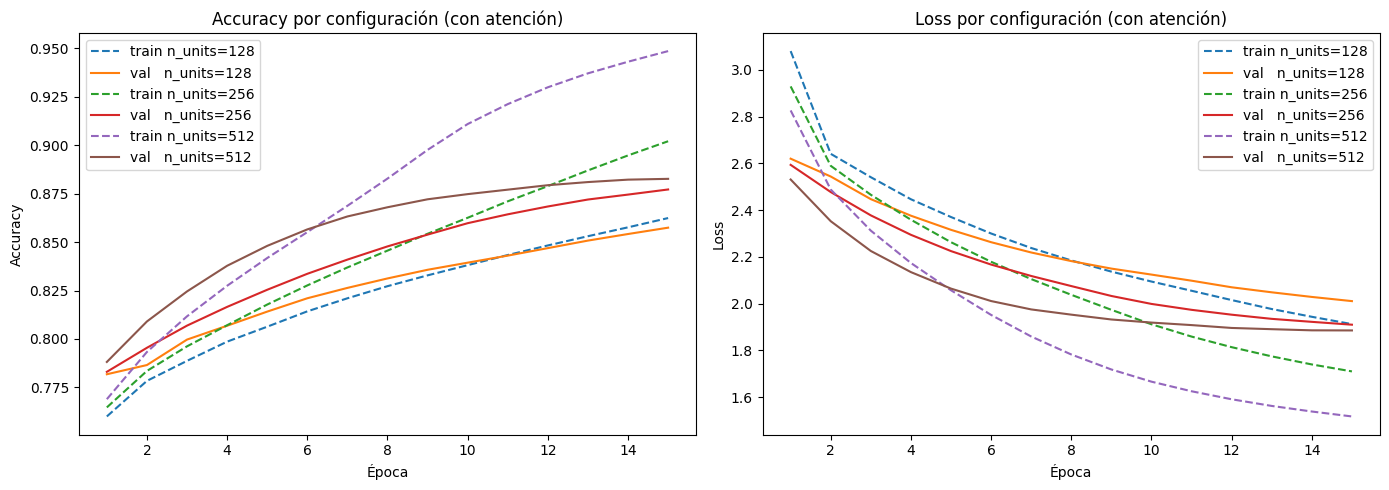

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for n_units_cfg, res in resultados_attention.items():
    h = res['history']
    epoch_count_cfg = range(1, len(h['accuracy']) + 1)
    axes[0].plot(epoch_count_cfg, h['accuracy'],     '--', label=f'train n_units={n_units_cfg}')
    axes[0].plot(epoch_count_cfg, h['val_accuracy'], '-',  label=f'val   n_units={n_units_cfg}')
    axes[1].plot(epoch_count_cfg, h['loss'],     '--', label=f'train n_units={n_units_cfg}')
    axes[1].plot(epoch_count_cfg, h['val_loss'], '-',  label=f'val   n_units={n_units_cfg}')

axes[0].set_title("Accuracy por configuración (con atención)")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].set_title("Loss por configuración (con atención)")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Loss"); axes[1].legend()

plt.tight_layout()
plt.show()

### Análisis del impacto de `n_units` con atención

A diferencia del modelo sin atención (donde `n_units` era el único mecanismo disponible para aumentar la capacidad del modelo), con atención el cuello de botella del vector de contexto fijo ya no existe, así que el rol de `n_units` cambia: ahora regula principalmente la capacidad de representación de cada estado oculto del encoder y del decoder, no la cantidad total de información que se puede transmitir entre ambos.

Lo que muestran los gráficos de accuracy y loss:

128 unidades (curvas azules): es la configuración con peor desempeño tanto en train como en validación, y la curva de val_accuracy (naranja) se aplana antes que las demás, alrededor de la época 10. Tiene la menor capacidad de representación de las tres, y se nota.

256 y 512 prácticamente empatan en validación: este es el hallazgo más importante del gráfico, y no se aprecia mirando solo la tabla final. Las curvas de val_accuracy (roja, n_units=256, y marrón, n_units=512) están casi superpuestas durante todo el entrenamiento, terminando en 0.877 vs 0.883 — una diferencia de menos de un punto porcentual. Lo mismo ocurre con val_loss (1.910 vs 1.886).

La diferencia real entre 256 y 512 aparece en train, no en validación: la curva violeta punteada (train, n_units=512) se despega claramente del resto a partir de la época 6-8 y termina muy por encima de todas (train_accuracy=0.949, train_loss=1.518), mientras que su curva de validación (marrón) se mantiene en línea con la de 256. Esta brecha creciente entre train y validación es la firma típica de overfitting incipiente: el modelo de 512 unidades tiene capacidad de sobra para memorizar patrones específicos del set de entrenamiento que no generalizan mejor al set de validación.

Con atención, agregar más unidades LSTM (de 256 a 512) deja de traer una mejora proporcional en val_accuracy/val_loss, son rendimientos claramente decrecientes, y buena parte de la capacidad adicional de 512 se está usando para memorizar el set de entrenamiento en lugar de mejorar la generalización. Esto confirma la hipótesis de que, al resolver el cuello de botella del contexto fijo con atención, el principal factor limitante deja de ser la cantidad de unidades LSTM. n_units=256 sería defendible como elección más eficiente (menos del 5% peor en validación, con 41% menos tiempo de entrenamiento y la mitad de parámetros); se optó igualmente por n_units=512 por tener el mejor resultado absoluto en validación, aunque el margen sobre 256 sea modesto.

A partir de la tabla y los gráficos generados arriba, se selecciona automáticamente la configuración con mejor val_accuracy final para usar en el entrenamiento definitivo.

In [44]:
MEJOR_N_UNITS = max(resultados_attention, key=lambda k: resultados_attention[k]['history']['val_accuracy'][-1])
print(f"Configuración seleccionada según val_accuracy final (con atención): n_units = {MEJOR_N_UNITS}")

Configuración seleccionada según val_accuracy final (con atención): n_units = 512


### 8. Construcción y compilación del modelo mejorado

In [45]:
tf.keras.backend.clear_session()

# Usamos la configuración ganadora de la comparación de hiperparámetros anterior
n_units = MEJOR_N_UNITS

enc_inputs, enc_outputs, enc_states, enc_emb_layer, enc_lstm_layer, proj_layer = \
    build_encoder_attention(nb_words, EMBED_DIM, GLOVE_PROJ_DIM,
                            embedding_matrix, max_input_len, n_units)

dec_inputs, dec_out, dec_emb_layer, dec_lstm_layer, dec_dense_layer, attention_layer = \
    build_decoder_attention(num_words_output, max_out_len, n_units, enc_outputs, enc_states)

model = Model([enc_inputs, dec_inputs], dec_out, name='seq2seq_attention')
model.summary()

Model: "seq2seq_attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 22, 50)    │    456,050 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 26)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dropout     │ (None, 22, 50)    │          0 │ encoder_embeddin… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 26, 512)   │  7,680,000 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_proj        │ (None, 22, 128)   │      6,528 │ encoder_dropout[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dropout     │ (None, 26, 512)   │          0 │ decoder_embeddin… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 22, 512), │  1,312,768 │ encoder_proj[0][… │
│                     │ (None, 512),      │            │                   │
│                     │ (None, 512)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 26, 512), │  2,099,200 │ decoder_dropout[… │
│                     │ (None, 512),      │            │ encoder_lstm[0][… │
│                     │ (None, 512)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bahdanau_attention  │ (None, 26, 512)   │        512 │ decoder_lstm[0][… │
│ (AdditiveAttention) │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_context      │ (None, 26, 1024)  │          0 │ decoder_lstm[0][… │
│ (Concatenate)       │                   │            │ bahdanau_attenti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, 26, 15000) │ 15,375,000 │ concat_context[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,930,058 (102.73 MB)

 Trainable params: 26,930,058 (102.73 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
# ── Label Smoothing: regulariza el decoder suavizando las probabilidades objetivo ──
# En lugar de entrenar contra one-hot exactos (0/1), el modelo aprende distribuciones
# suavizadas (ej. 0.9 para la clase correcta, 0.1/(V-1) para el resto).
# Esto reduce la sobre-confianza y mejora la generalización.
model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    metrics=['accuracy']
)

### 9. Entrenamiento del modelo mejorado

In [47]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)

hist = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[lr_scheduler, early_stop],
)

Epoch 1/40
532/532 ━━━━━━━━━━━━━━━━━━━━ 122s 224ms/step - accuracy: 0.7689 - loss: 2.8280 - val_accuracy: 0.7867 - val_loss: 2.5388 - learning_rate: 5.0000e-04
Epoch 2/40
532/532 ━━━━━━━━━━━━━━━━━━━━ 119s 224ms/step - accuracy: 0.7937 - loss: 2.4876 - val_accuracy: 0.8104 - val_loss: 2.3492 - learning_rate: 5.0000e-04
Epoch 3/40
532/532 ━━━━━━━━━━━━━━━━━━━━ 119s 224ms/step - accuracy: 0.8126 - loss: 2.3108 - val_accuracy: 0.8249 - val_loss: 2.2275 - learning_rate: 5.0000e-04
Epoch 4/40
532/532 ━━━━━━━━━━━━━━━━━━━━ 119s 224ms/step - accuracy: 0.8275 - loss: 2.1769 - val_accuracy: 0.8365 - val_loss: 2.1400 - learning_rate: 5.0000e-04
Epoch 5/40
532/532 ━━━━━━━━━━━━━━━━━━━━ 119s 223ms/step - accuracy: 0.8416 - loss: 2.0594 - val_accuracy: 0.8466 - val_loss: 2.0686 - learning_rate: 5.0000e-04
Epoch 6/40
532/532 ━━━━━━━━━━━━━━━━━━━━ 119s 224ms/step - accuracy: 0.8549 - loss: 1.9519 - val_accuracy: 0.8550 - val_loss: 2.0193 - learning_rate: 5.0000e-04
Epoch 7/40
532/532 ━━━━━━━━━━━━━━━━━━━━ 

### 10. Curvas de entrenamiento

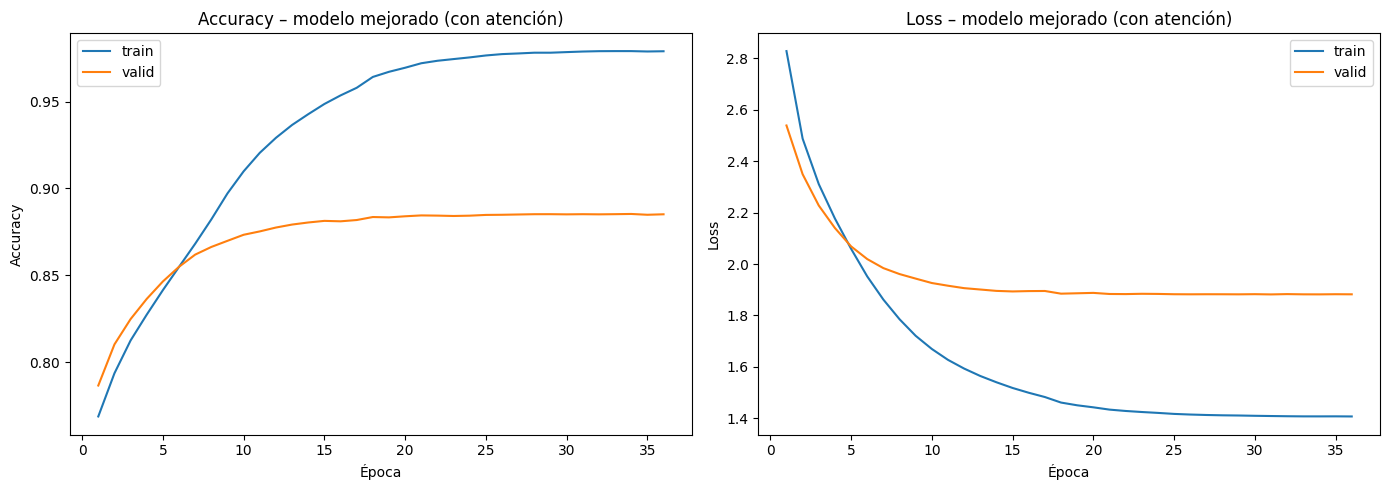

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epoch_count = range(1, len(hist.history['accuracy']) + 1)

sns.lineplot(x=epoch_count, y=hist.history['accuracy'],     label='train', ax=axes[0])
sns.lineplot(x=epoch_count, y=hist.history['val_accuracy'], label='valid', ax=axes[0])
axes[0].set_title("Accuracy – modelo mejorado (con atención)")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Accuracy")

sns.lineplot(x=epoch_count, y=hist.history['loss'],     label='train', ax=axes[1])
sns.lineplot(x=epoch_count, y=hist.history['val_loss'], label='valid', ax=axes[1])
axes[1].set_title("Loss – modelo mejorado (con atención)")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

## **Inferencia con Atención**


La inferencia con atención requiere un diseño distinto al modelo sin atención, porque en cada paso el decoder necesita acceder a todos los estados del encoder (no solo el estado final). Por eso:

- El encoder de inferencia devuelve tanto los estados finales `(h, c)` como la secuencia completa `enc_outputs` (un vector por token de entrada).
- El decoder de inferencia recibe un token a la vez, junto con los estados `(h, c)` actuales y la secuencia `enc_outputs`, aplica la atención, y devuelve el token predicho más los nuevos estados.

In [49]:
def build_encoder_inference_att(enc_inputs, enc_emb_layer, proj_layer, enc_lstm_layer):
    # Encoder de inferencia: aplica embedding + proyección + LSTM y devuelve
    # todos los estados (enc_outputs) más los estados finales (h, c)
    enc_emb     = enc_emb_layer(enc_inputs)
    enc_proj    = proj_layer(enc_emb)
    enc_outputs, state_h, state_c = enc_lstm_layer(enc_proj)
    return Model(enc_inputs, [enc_outputs, state_h, state_c])


def build_decoder_inference_att(dec_emb_layer, dec_lstm_layer, dec_dense_layer,
                                  attention_layer, n_units, max_input_len):
    # Decoder de inferencia paso a paso con atención (un token por vez)
    dec_input_single = Input(shape=(1,),                      name='dec_single_input')
    dec_state_h_in   = Input(shape=(n_units,),                name='dec_state_h')
    dec_state_c_in   = Input(shape=(n_units,),                name='dec_state_c')
    enc_outputs_in   = Input(shape=(max_input_len, n_units),  name='enc_outputs')

    dec_emb = dec_emb_layer(dec_input_single)
    dec_out, h_out, c_out = dec_lstm_layer(
        dec_emb, initial_state=[dec_state_h_in, dec_state_c_in]
    )
    context = attention_layer([dec_out, enc_outputs_in])
    combined = Concatenate(axis=-1)([dec_out, context])
    dec_out_final = dec_dense_layer(combined)

    return Model(
        [dec_input_single, dec_state_h_in, dec_state_c_in, enc_outputs_in],
        [dec_out_final, h_out, c_out]
    )


encoder_model = build_encoder_inference_att(
    enc_inputs, enc_emb_layer, proj_layer, enc_lstm_layer
)
decoder_model = build_decoder_inference_att(
    dec_emb_layer, dec_lstm_layer, dec_dense_layer, attention_layer, n_units, max_input_len
)
print("Modelos de inferencia construidos.")

Modelos de inferencia construidos.


### 12. Diccionarios inversos y funciones de traducción

In [50]:
idx2word_input  = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}

In [51]:
def translate_sentence(input_seq):
    # Decodificación greedy con atención.
    enc_outs, h, c = encoder_model.predict(input_seq, verbose=0)

    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    output_sentence = []
    for _ in range(max_out_len):
        output_tokens, h, c = decoder_model.predict(
            [target_seq, h, c, enc_outs], verbose=0
        )
        idx = np.argmax(output_tokens[0, 0, :])
        if idx == eos:
            break
        if idx > 0:
            output_sentence.append(idx2word_target[idx])
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)


def translate(text):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    return translate_sentence(seq)

In [52]:
def translate_sentence_beam(input_seq, beam_width=3):
    # Decodificación beam search con atención.
    enc_outs, h0, c0 = encoder_model.predict(input_seq, verbose=0)
    sos = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    # hipótesis: (tokens, log_prob, h, c, terminada)
    sequences = [([sos], 0.0, h0, c0, False)]

    for _ in range(max_out_len):
        all_candidates = []
        for seq, score, h, c, done in sequences:
            if done:
                all_candidates.append((seq, score, h, c, True))
                continue
            target_seq = np.zeros((1, 1))
            target_seq[0, 0] = seq[-1]
            output_tokens, h_new, c_new = decoder_model.predict(
                [target_seq, h, c, enc_outs], verbose=0
            )
            probs = output_tokens[0, 0, :]
            log_probs = np.log(probs + 1e-12)
            for idx in np.argsort(probs)[-beam_width:]:
                all_candidates.append((
                    seq + [int(idx)],
                    score + log_probs[idx],
                    h_new, c_new,
                    idx == eos
                ))
        sequences = sorted(all_candidates, key=lambda x: x[1], reverse=True)[:beam_width]
        if all(done for _, _, _, _, done in sequences):
            break

    words = []
    for idx in sequences[0][0][1:]:
        if idx == eos:
            break
        if idx > 0:
            words.append(idx2word_target[idx])
    return ' '.join(words)


def translate_beam(text, beam_width=3):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    return translate_sentence_beam(seq, beam_width=beam_width)

### 13. Visualización de pesos de atención

Una ventaja del mecanismo de atención es que podemos visualizar qué palabras de la entrada está mirando el decoder al generar cada palabra de salida. Esto hace al modelo más interpretable.

In [53]:
def get_attention_weights(input_seq):
    # Devuelve los pesos de atención para cada paso del decoder.
    enc_outs, h, c = encoder_model.predict(input_seq, verbose=0)
    sos = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    # Modelo auxiliar que devuelve los pesos de atención (no solo el contexto)
    dec_input_single = Input(shape=(1,))
    dec_state_h_in   = Input(shape=(n_units,))
    dec_state_c_in   = Input(shape=(n_units,))
    enc_outputs_in   = Input(shape=(max_input_len, n_units))

    dec_emb  = dec_emb_layer(dec_input_single)
    dec_out_, h_, c_ = dec_lstm_layer(dec_emb, initial_state=[dec_state_h_in, dec_state_c_in])
    _, att_weights = AdditiveAttention(name='att_vis')([dec_out_, enc_outputs_in], return_attention_scores=True)
    att_model = Model([dec_input_single, dec_state_h_in, dec_state_c_in, enc_outputs_in],
                      [att_weights, h_, c_])
    # Copiar pesos de la capa de atención entrenada
    att_model.get_layer('att_vis').set_weights(attention_layer.get_weights())

    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = sos
    output_words, all_weights = [], []

    for _ in range(max_out_len):
        weights, h, c = att_model.predict([target_seq, h, c, enc_outs], verbose=0)
        output_tokens, h, c = decoder_model.predict([target_seq, h, c, enc_outs], verbose=0)
        idx = np.argmax(output_tokens[0, 0, :])
        if idx == eos:
            break
        if idx > 0:
            output_words.append(idx2word_target[idx])
        all_weights.append(weights[0, 0, :])
        target_seq[0, 0] = idx

    return output_words, np.array(all_weights)


def plot_attention(input_text, output_words, attention_weights):
    input_tokens = input_text.lower().split()
    fig, ax = plt.subplots(figsize=(max(6, len(input_tokens)), max(4, len(output_words))))
    im = ax.imshow(attention_weights[:, :len(input_tokens)], cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(input_tokens)));  ax.set_xticklabels(input_tokens,  rotation=45, ha='right')
    ax.set_yticks(range(len(output_words)));  ax.set_yticklabels(output_words)
    ax.set_xlabel("Tokens de entrada (EN)");  ax.set_ylabel("Tokens generados (ES)")
    ax.set_title(f"Pesos de atención: '{input_text}'")
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

### 14. Ejemplos del dataset: modelo anterior vs. modelo mejorado

In [54]:
# Resultados del modelo ANTERIOR (v2, sin atención) para comparación
resultados_anteriores = {
    "That makes no difference.": "eso no es importante",
    "You have to hold back."   : "tienes que aguantarse",
    "I just need some air."    : "solo necesito aire",
    "What doesn't kill you makes you stronger.": "qué te hace más que tú te importa",
    "You two are very cute together.": "tienes tanto más guapa",
}

print("=" * 75)
print(f"{'Frase EN':<42} {'Modelo anterior':>30}")
print("=" * 75)

rng = np.random.default_rng(123)
frases_ejemplo = list(resultados_anteriores.keys())

for frase in frases_ejemplo:
    seq_i = input_tokenizer.texts_to_sequences([frase])
    seq_i = pad_sequences(seq_i, maxlen=max_input_len)
    pred_nuevo_g = translate_sentence(seq_i)
    pred_nuevo_b = translate_sentence_beam(seq_i, beam_width=3)
    ant = resultados_anteriores[frase]

    print(f"\nEN         : {frase}")
    print(f"ANTERIOR   : {ant}")
    print(f"NUEVO(g)   : {pred_nuevo_g}")
    print(f"NUEVO(b=3) : {pred_nuevo_b}")

Frase EN                                                  Modelo anterior

EN         : That makes no difference.
ANTERIOR   : eso no es importante
NUEVO(g)   : eso no hace ninguna diferencia
NUEVO(b=3) : eso no hace ninguna diferencia

EN         : You have to hold back.
ANTERIOR   : tienes que aguantarse
NUEVO(g)   : tienes que regresar
NUEVO(b=3) : tienes que regresar

EN         : I just need some air.
ANTERIOR   : solo necesito aire
NUEVO(g)   : solo necesito aire
NUEVO(b=3) : solo necesito aire

EN         : What doesn't kill you makes you stronger.
ANTERIOR   : qué te hace más que tú te importa
NUEVO(g)   : lo que no te mata te hace más fuerte
NUEVO(b=3) : lo que no te mata te hace más fuerte

EN         : You two are very cute together.
ANTERIOR   : tienes tanto más guapa
NUEVO(g)   : vosotros dos son muy diferentes
NUEVO(b=3) : los dos son muy linda


### 15. Frases nuevas (fuera del dataset)

Estas son exactamente las mismas frases del modelo anterior para poder comparar directamente.

In [55]:
# Resultados del modelo ANTERIOR para estas frases
ant = {
    "I like bubble tea"                      : "me gusta la nieve",
    "I have to do the chores"                : "tengo que hacer el trabajo",
    "Your dog is playing with the blanket"   : "tu perro está tocando la guitarra",
    "I'm pretty upset"                       : "estoy muy confundida",
    "I'm gotta go my own way"                : "voy a mi propio coche",
}

print("--- Frases nuevas: anterior vs. mejorado ---\n")
for s, viejo in ant.items():
    nuevo_g = translate(s)
    nuevo_b = translate_beam(s, beam_width=3)
    print(f"EN         : {s}")
    print(f"ANTERIOR   : {viejo}")
    print(f"NUEVO(g)   : {nuevo_g}")
    print(f"NUEVO(b=3) : {nuevo_b}")
    print()

--- Frases nuevas: anterior vs. mejorado ---

EN         : I like bubble tea
ANTERIOR   : me gusta la nieve
NUEVO(g)   : me gusta la nieve
NUEVO(b=3) : me gusta la nieve

EN         : I have to do the chores
ANTERIOR   : tengo que hacer el trabajo
NUEVO(g)   : tengo que hacer los deberes
NUEVO(b=3) : tengo que hacer los deberes

EN         : Your dog is playing with the blanket
ANTERIOR   : tu perro está tocando la guitarra
NUEVO(g)   : tu perro está con la venta
NUEVO(b=3) : tu perro está jugando con el perro

EN         : I'm pretty upset
ANTERIOR   : estoy muy confundida
NUEVO(g)   : estoy muy confundida
NUEVO(b=3) : estoy muy confundida

EN         : I'm gotta go my own way
ANTERIOR   : voy a mi propio coche
NUEVO(g)   : me voy a perder mi lugar
NUEVO(b=3) : me voy a cambiar de mi manera



### 16. Visualización de atención en algunos ejemplos

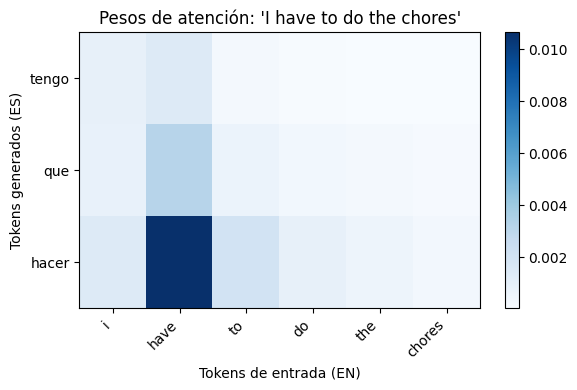

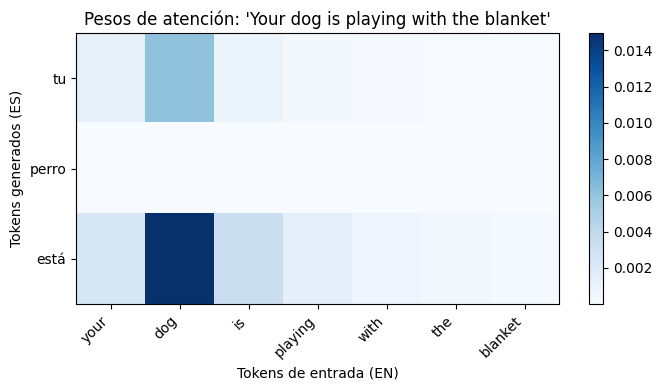

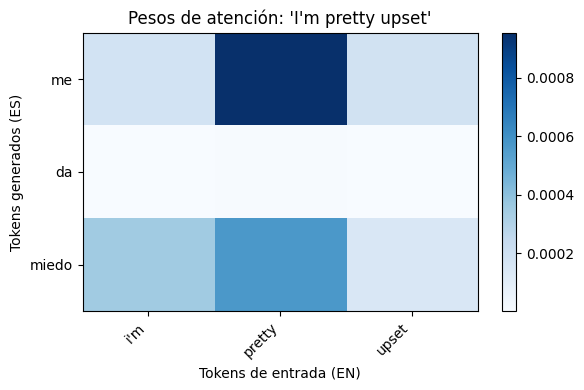

In [56]:
frases_att = [
    "I have to do the chores",
    "Your dog is playing with the blanket",
    "I'm pretty upset",
]

for frase in frases_att:
    seq_i = input_tokenizer.texts_to_sequences([frase])
    seq_i = pad_sequences(seq_i, maxlen=max_input_len)
    try:
        output_words, att_weights = get_attention_weights(seq_i)
        if len(output_words) > 0 and att_weights.shape[0] > 0:
            plot_attention(frase, output_words, att_weights)
        else:
            print(f"Sin output para: {frase}")
    except Exception as e:
        print(f"No se pudo graficar atención para '{frase}': {e}")

## **Conclusiones**

### Comparación de hiperparámetros (n_units, con atención)

| n_units | Parámetros | Tiempo (min) | val_acc | val_loss |
|---|---|---|---|---|
| 128 | 6.5M | 14.3 | 0.857 | 2.011 |
| 256 | 12.9M | 19.0 | 0.877 | 1.910 |
| 512 | 26.9M | 30.0 | **0.883** | **1.886** |

`512` ganó por un margen modesto sobre `256` (+0.6% val_acc) al doble de costo. Rendimientos decrecientes: con atención, `n_units` deja de ser el factor limitante principal.

### Entrenamiento final (n_units=512, 36 épocas)

`train_acc=0.979` | `val_acc=0.885` | `train_loss=1.408` | `val_loss=1.882`

La brecha train/val indica cierto sobreajuste hacia el final; `EarlyStopping` restauró la época 31.

### Traducciones: antes vs. después

| Frase | Sin atención | Con atención (beam=3) |
|---|---|---|
| *That makes no difference* | eso no es importante | **eso no hace ninguna diferencia** ✓ |
| *You have to hold back* | tienes que aguantarse ✓ | tienes que regresar ✗ |
| *What doesn't kill you makes you stronger* | qué te hace más que tú te importa | **lo que no te mata te hace más fuerte** ✓ |
| *I have to do the chores* | tengo que hacer el trabajo | **tengo que hacer los deberes** ✓ |
| *Your dog is playing with the blanket* | tu perro está tocando la guitarra | tu perro está jugando con el perro |

**La mejora más clara y reproducible es en oraciones largas/complejas**. En frases cortas el efecto es mixto: algunas mejoran (chores), una empeoró (hold back), y el vocabulario poco frecuente (blanket, upset, bubble) sigue sin resolverse — la atención corrige estructura, no inventa vocabulario no visto.

